# Tasks remaining to do:

1. Encode the filename by using the encoder from wisio "https://github.com/izzet/wisio/blob/main/tools/recorder2parquet.cpp#L727"

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os
import yaml
from pathlib import Path
from dask.distributed import Client
import dask.dataframe as dd
import networkx as nx
import sys
import pandas as pd
import re
import glob


import ipycytoscape
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import intervals
import pygtrie
import seaborn as sns

/usr/workspace/pandey2/DFT/envDFT/lib/python3.9/site-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [3]:
# App Name
app_name = "montage" # resnet cosmoflow unet3d mummi deepspeed dlio_resnet dlio_cosmoflow


In [7]:

use_local=False
if not use_local:
    with open(f'/g/g91/pandey2/.dftracer/configuration.yaml', 'r') as file:
    # 1 with open(f'/g/g91/pandey2/.dlio_profiler/configuration.yaml', 'r') as file:
        dlp_yaml = yaml.safe_load(file)
        app_root = dlp_yaml["app"]
else:
    app_root = str(Path(os.getcwd()).parent.parent)
sys.path.insert(0, app_root)


import dfanalyzer
print(dfanalyzer.__file__)
from dfanalyzer.main import DFAnalyzer,get_dft_configuration,update_dft_configuration,setup_logging,setup_dask_cluster, reset_dask_cluster, get_dft_configuration
# from dfanalyzer.graph_visualization.plots import GrepIOPlots
from dfanalyzer.graph_visualization.cytoscape import GraphFunctions, CytoGraph
from dfanalyzer.graph import DFGrepInterference, DFGrepWorkflow 


if not use_local:
    dask_run_dir = os.path.join(app_root, "dfanalyzer", "dask", "run_dir")
    with open (os.path.join(dask_run_dir, f"scheduler_{os.getenv('USER')}.json"), "r") as f:
        dask_scheduler = json.load(f)["address"]
else:
    dask_scheduler = None





condition_fn = None #

if app_name == "montage":
    filename ="/usr/workspace/iopp/graph-io/dlp_logs/montage_16_48ppn/montage*.pfw"
    
else:
    raise Exception("Unknown App name")


# Configuration 4 update log file dlp -> df
conf = update_dft_configuration(dask_scheduler=dask_scheduler, verbose=True, 
                                log_file=f"./dft_{os.getenv('USER')}.log", rebuild_index=False, time_approximate=False, 
                                host_pattern=r'lassen(\d+)', time_granularity=30e6, skip_hostname=True, conditions=condition_fn)
conf = get_dft_configuration()


# Setup
setup_logging()
setup_dask_cluster()
reset_dask_cluster()

/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/__init__.py


[INFO] [07:06:10] Initialized Client with 768 workers and link http://134.9.71.27:8787/status [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:673]
[INFO] [07:06:22] Restarting all workers [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:665]


In [8]:
# This cell is for mount point detection functions
def find_mount_point(path,trie):
    mount_point = trie.longest_prefix(path)
    if mount_point:
        return mount_point.key
    return "/"

def all_mount_points():
    with open("/proc/mounts", "r") as file:
        mount_points = [line.split()[1] for line in file]
    with open("/usr/workspace/pandey2/lassen_mounts", "r") as file:
        mount_p = [line.split()[1] for line in file]
    return mount_points+mount_p

mount_points = all_mount_points()
trie = pygtrie.StringTrie(zip(mount_points, [True] * len(mount_points)))

def montage_cols_function(json_object, current_dict, time_approximate,condition_fn,load_data):
    d = {}
    def find_mount_point(path,trie):
        mount_point = trie.longest_prefix(path)
        if mount_point:
            return mount_point.key
        return "/"
    
    if "args" in json_object:
        if "fname" in json_object["args"]:
            d["filename"] = str(json_object["args"]["fname"])   
            d["mount_point"] = find_mount_point(trie=load_data["mount_point"],path=str(json_object["args"]["fname"]))


    if "name" in json_object:
        if (json_object["name"] == "fwrite"):
            d["prod"] = 1
            d["cons"] = 0
        else:
            d["prod"] = 0
            d["cons"] = 1       
    return d
#oad_cols_montage = {'path':"string[pyarrow]", 'filename':"string[pyarrow]",'mount_point':"string[pyarrow]", 'flags':"uint64[pyarrow]", 'mode':"uint64[pyarrow]", 'prod':"uint16[pyarrow]", 'cons':"uint16[pyarrow]"}
load_cols_montage = {'filename':"string[pyarrow]",'mount_point':"string[pyarrow]", 'prod':"uint16[pyarrow]", 'cons':"uint16[pyarrow]"}


In [9]:
analyzer_montage = DFAnalyzer(filename,load_fn=montage_cols_function, load_cols=load_cols_montage, load_data={"mount_point":trie})

[INFO] [07:07:04] Created index for 0 files [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:371]
[INFO] [07:07:04] Total size of all files are <dask.bag.core.Item object at 0x1554aa700460> bytes [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:373]
[INFO] [07:07:52] Loaded events [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:431]
[INFO] [07:07:52] Loaded plots with slope threshold: 45 [/usr/workspace/pandey2/DFT/dftracer/dfanalyzer/main.py:437]


In [11]:
analyzer_montage.events.pid.nunique().compute()

np.int64(885)

In [8]:
# analyzer_montage.events.head()

,name,cat,pid,tid,ts,te,dur,tinterval,trange,hostname,compute_time,io_time,app_io_time,total_time,filename,phase,size,mount_point,prod,cons
0,__xstat64,POSIX,38924,11634,5501,5514,13,<NA>,0,lassen429,<NA>,13,<NA>,13,/var/tmp/mummi/createsim/structure_iter00_0000...,2,<NA>,/,0,1
1,__xstat64,POSIX,38924,11634,17988,21588,3600,<NA>,0,lassen429,<NA>,3600,<NA>,3600,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,2,<NA>,/p/gpfs1,0,1
2,open64,POSIX,38924,11634,21683,21825,142,<NA>,0,lassen429,<NA>,142,<NA>,142,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,2,<NA>,/p/gpfs1,0,1
3,__fxstat64,POSIX,38924,11634,21887,21890,3,<NA>,0,lassen429,<NA>,3,<NA>,3,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,2,<NA>,/p/gpfs1,0,1
4,lseek64,POSIX,38924,11634,21961,21966,5,<NA>,0,lassen429,<NA>,5,<NA>,5,/p/gpfs1/iopp/mummi_demoroot_20230722_profile/...,2,<NA>,/p/gpfs1,0,1


In [12]:

# Montage Graph
dfworkflow = DFGrepWorkflow(analyzer_montage.events, app_name = "montage", trace_path=filename)
# #perform reduction
# wf = dfworkflow.create_workflow()
# pid_map = dfworkflow.get_pid_map()
# graph_df = dfworkflow.create_graph_df(wf.compute(),pid_map)
# temp_graph = graph_df.groupby(['src','dest'])['wt'].min().reset_index()
# # temp_graph.sort_values('wt')

In [13]:
wf = dfworkflow.create_workflow()

In [14]:
def get_pid_map(trace_path):
    '''
    This function is designed for mummi traces to map pid with the application based on the filename
    '''
    pid_map ={}
    all_files = glob.glob(trace_path)
    for file in all_files:
        slices = re.split(r'[.-]', os.path.basename(file))
        # slices = os.path.basename(file).split('.')
        if (len(slices) > 3):
            pid_map[slices[2]] = slices[1]
    return pid_map

In [15]:
pid_map = get_pid_map(filename)


In [17]:
graph_df = dfworkflow.create_graph_df(wf.compute(),pid_map)
graph_df

,src,dest,wt
0,f_x-updated-corrected.tbl,p_mAdd,232333273
1,f_x-mosaic.fits,p_mAdd,232344707
2,p_mAdd,f_x-mosaic.fits,232344707
3,f_x-mosaic_area.fits,p_mAdd,232346013
4,p_mAdd,f_x-mosaic_area.fits,232346013
...,...,...,...
316,f_cpossxukstu_red_x_x.fits,p_826718,219343275
317,f_cpossxukstu_blue_x_x.fits,p_826719,219535053
318,f_cpossxukstu_blue_x_x_area.fits,p_826719,219536120
319,f_cpossxukstu_blue_x_x.fits,p_826720,219385094


In [18]:
temp_graph = graph_df.groupby(['src','dest'])['wt'].min().reset_index()
temp_graph

,src,dest,wt
0,f_cpossxukstu_blue_x_x.fits,p_617129,233797536
1,f_cpossxukstu_blue_x_x.fits,p_826711,219608501
2,f_cpossxukstu_blue_x_x.fits,p_826719,219535053
3,f_cpossxukstu_blue_x_x.fits,p_826720,219385094
4,f_cpossxukstu_blue_x_x.fits,p_mBackground,218881327
...,...,...,...
116,p_mProject,f_ppossxukstu_ir_x_x_area.fits,94275771
117,p_mProject,f_ppossxukstu_red_x_x.fits,94228221
118,p_mProject,f_ppossxukstu_red_x_x_area.fits,94229659
119,p_mViewer,f_mosaic-color.png,343614277


In [19]:
wf.compute()

,filename,pid,prod_pid,cons_pid,ts,prod_fid,cons_fid
0,3-updated-corrected.tbl,617137,0,4,232333273,7,14
1,3-mosaic.fits,617137,10801,5,232344707,10801,21633
2,3-mosaic_area.fits,617137,10801,5,232346013,10801,9
3,2-updated-corrected.tbl,617138,0,4,232333260,7,14
4,2-mosaic.fits,617138,10801,5,232343226,10801,21633
...,...,...,...,...,...,...,...
285,cposs2ukstu_red_002_001.fits,826718,0,4,219343275,5170,9
286,cposs2ukstu_blue_001_001.fits,826719,0,4,219535053,5172,8
287,cposs2ukstu_blue_001_001_area.fits,826719,0,4,219536120,5172,8
288,cposs2ukstu_blue_001_002.fits,826720,0,4,219385094,5174,8


In [20]:
graph_finer = dfworkflow.create_graph_finer_granularity(wf.compute())

In [22]:
betweeness_finer = dfworkflow.compute_betweeness_centrality(graph_finer)
betweness_app = dfworkflow.compute_betweeness_centrality(temp_graph)

In [21]:
graph_finer

,src,dest,wt
0,3-updated-corrected.tbl,p_617137,232333273
1,3-mosaic.fits,p_617137,232344707
2,p_617137,3-mosaic.fits,232344707
3,3-mosaic_area.fits,p_617137,232346013
4,p_617137,3-mosaic_area.fits,232346013
...,...,...,...
316,cposs2ukstu_red_002_001.fits,p_826718,219343275
317,cposs2ukstu_blue_001_001.fits,p_826719,219535053
318,cposs2ukstu_blue_001_001_area.fits,p_826719,219536120
319,cposs2ukstu_blue_001_002.fits,p_826720,219385094


In [23]:
temp_graph.sort_values('wt')

,src,dest,wt
117,p_mProject,f_ppossxukstu_red_x_x.fits,94228221
66,f_ppossxukstu_red_x_x.fits,p_mProject,94228221
73,f_ppossxukstu_red_x_x_area.fits,p_mProject,94229659
118,p_mProject,f_ppossxukstu_red_x_x_area.fits,94229659
52,f_ppossxukstu_ir_x_x.fits,p_mProject,94274812
...,...,...,...
90,f_x-mosaic.png,p_617148,337101722
91,f_x-mosaic.png,p_617152,338384737
119,p_mViewer,f_mosaic-color.png,343614277
31,f_mosaic-color.png,p_mViewer,343614277


In [24]:
graph_finer.to_csv("/p/lustre2/pandey2/cp_centrality/montage/graph_finer.csv")
temp_graph.to_csv("/p/lustre2/pandey2/cp_centrality/montage/graph_app.csv")
json.dump(betweeness_finer, open('/p/lustre2/pandey2/cp_centrality/montage/betweeness_finer.txt','w'), indent=4)
json.dump(betweness_app, open('/p/lustre2/pandey2/cp_centrality/montage/betweeness_app.txt','w'), indent=4)

In [30]:
def histogram_dict(betweeness_dict):
    p_nodes = [value for node, value in betweeness_dict.items() if node.startswith('p')]
    f_nodes = [value for node, value in betweeness_dict.items() if not node.startswith('p')]
    # Create a figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Plotting histogram for p-nodes
    ax1.hist(p_nodes, bins=10, alpha=0.7, color='blue')
    # ax1.set_xscale('log')
    ax1.set_xlabel('Betweenness Centrality')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Processes')

    # Plotting histogram for non p-nodes
    ax2.hist(f_nodes, bins=10, alpha=0.7, color='green')
    # ax2.set_xscale('log')
    ax2.set_xlabel('Betweenness Centrality')
    ax2.set_ylabel('Frequency')
    ax2.set_title('Files')

    # Adjust layout
    plt.tight_layout()

    # Show the plot
    plt.show()
    

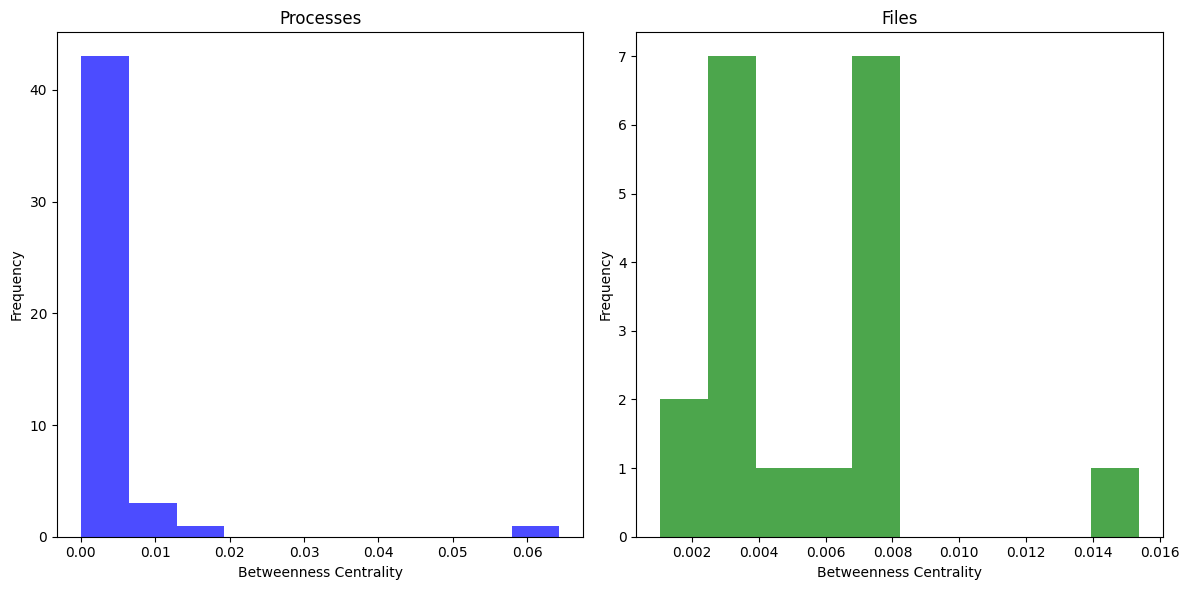

In [33]:
histogram_dict(betweness_app)

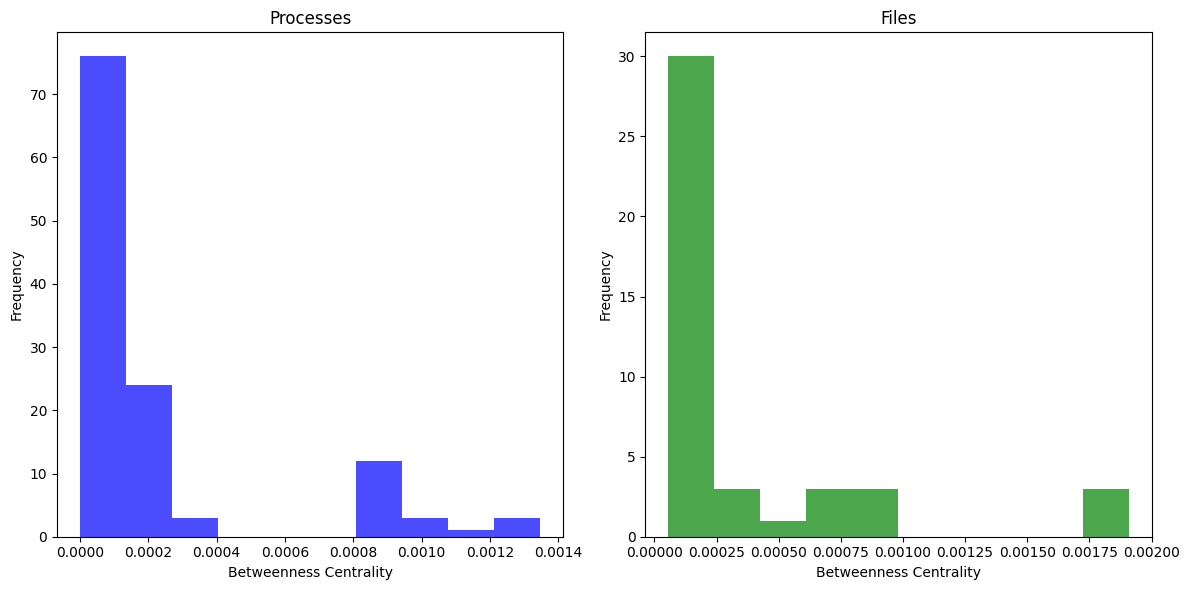

In [31]:
histogram_dict(betweeness_finer)

In [17]:
temp_graph.to_csv("montage2m7d.csv", index=False)

In [74]:
# tg = temp_graph.sort_values('wt').reset_index(drop = True)
# tg['trange'] = tg.index
# c = CytoGraph()
# c.temporal_view(tg)

In [76]:
"axis".startswith('a')

True

In [18]:
ealist = []
for row in range(len(temp_graph)):
    # print(len(tg.src.loc[row]) > len(tg.dest.loc[row]))
    if(temp_graph.src.loc[row].startswith("f")):
        ealist.append((temp_graph.src.loc[row],str(temp_graph.wt.loc[row])+" "+ str(temp_graph.dest.loc[row])))
    else:
        ealist.append((str(temp_graph.wt.loc[row])+" "+ str(temp_graph.src.loc[row]), temp_graph.dest.loc[row]))

df = pd.DataFrame()
df['src'] = [ealist[i][0] for i in range(len(ealist))]
df['dest'] = [ealist[i][1] for i in range(len(ealist))]
df['wt'] = temp_graph['wt']
df

,src,dest,wt
0,f_pxmass-atlas-xn-hx.fits,556394004 p_mBackground,556394004
1,f_pxmass-atlas-xn-hx.fits,114863767 p_mDiff,114863767
2,f_pxmass-atlas-xn-hx.fits,204269655 p_mFitplane,204269655
3,f_pxmass-atlas-xn-hx.fits,106532345 p_mProject,106532345
4,f_pxmass-atlas-xn-hx_area.fits,556401404 p_mBackground,556401404
...,...,...,...
95,24168968 p_mProject,f_pxmass-atlas-xs-jx.fits,24168968
96,24170523 p_mProject,f_pxmass-atlas-xs-jx_area.fits,24170523
97,20568570 p_mProject,f_pxmass-atlas-xs-kx.fits,20568570
98,20604384 p_mProject,f_pxmass-atlas-xs-kx_area.fits,20604384


In [19]:
df.sort_values('wt')

,src,dest,wt
52,f_pxmass-atlas-xs-kx.fits,20568570 p_mProject,20568570
97,20568570 p_mProject,f_pxmass-atlas-xs-kx.fits,20568570
98,20604384 p_mProject,f_pxmass-atlas-xs-kx_area.fits,20604384
57,f_pxmass-atlas-xs-kx_area.fits,20604384 p_mProject,20604384
42,f_pxmass-atlas-xs-jx.fits,24168968 p_mProject,24168968
...,...,...,...
4,f_pxmass-atlas-xn-hx_area.fits,556401404 p_mBackground,556401404
38,f_pxmass-atlas-xs-jx.fits,631694187 p_mBackground,631694187
43,f_pxmass-atlas-xs-jx_area.fits,631700728 p_mBackground,631700728
8,f_pxmass-atlas-xn-jx.fits,637570617 p_mBackground,637570617


In [20]:
cy = CytoGraph()
g = nx.from_pandas_edgelist(df, source = 'src', target='dest', edge_attr='wt',  create_using=nx.DiGraph())
js = cy.get_rich_json(g)
app_view= ipycytoscape.CytoscapeWidget()
app_view.graph.add_graph_from_json(js)
app_view.set_style(style=cy.get_style('direct'))
app_view.set_layout(name="dagre",spacingFactor= 1.5, fit=True,)
app_view

CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'spacingFactor': 1.5, 'fit': True}, cytoscape_style=[{'sele…

In [85]:
df.src.unique()

array(['f_createsims_failure', 'f_createsims_success',
       'f_structure_iterx_x.npz', 'p_cganalysis 81780740',
       'p_cganalysis 1890849941', 'p_createsims 76894074',
       'p_createsims 1661884098', 'p_mlserver 29359864'], dtype=object)

In [17]:
def topologicalSortUtil(v): 
	global Stack, visited, adj 
	visited[v] = True

	for i in adj[v]: 
		if (not visited[i[0]]): 
			topologicalSortUtil(i[0]) 

	# Push current vertex to stack which stores topological 
	# sort 
	Stack.append(v) 

# The function to find longest distances from a given vertex. 
# It uses recursive topologicalSortUtil() to get topological 
# sorting. 
def longestPath(s): 
	global Stack, visited, adj, V 
	dist = [-10**9 for i in range(V)] 

	# Call the recursive helper function to store Topological 
	# Sort starting from all vertices one by one 
	for i in range(V): 
		if (visited[i] == False): 
			topologicalSortUtil(i) 
	# print(Stack) 

	# Initialize distances to all vertices as infinite and 
	# distance to source as 0 
	dist[s] = 0
	# Stack.append(1) 

	# Process vertices in topological order 
	while (len(Stack) > 0): 
		
		# Get the next vertex from topological order 
		u = Stack[-1] 
		del Stack[-1] 
		#print(u) 

		# Update distances of all adjacent vertices 
		# list<AdjListNode>::iterator i 
		if (dist[u] != 10**9): 
			for i in adj[u]: 
				# print(u, i) 
				if (dist[i[0]] < dist[u] + i[1]): 
					dist[i[0]] = dist[u] + i[1] 

	# Print calculated longest distances 
	# print(dist) 
	for i in range(V): 
		print("INF ",end="") if (dist[i] == -10**9) else print(dist[i],end=" ") 

# Driver code 
if __name__ == '__main__': 
	V, Stack, visited = 6, [], [False for i in range(7)] 
	adj = [[] for i in range(7)] 
	adj[0].append([1, 5]) 
	adj[0].append([2, 3]) 
	adj[1].append([3, 6]) 
	adj[1].append([2, 2]) 
	adj[2].append([4, 4]) 
	adj[2].append([5, 2]) 
	adj[2].append([3, 7]) 
	adj[3].append([5, 1]) 
	adj[3].append([1, 4])
	adj[3].append([4, -1]) 
	adj[4].append([5, -2]) 
	print(adj)
	# g = nx.DiGraph()

	s = 0
	print("Following are longest distances from source vertex ",s) 
	longestPath(0) 

	# This code is contributed by mohit kumar 29.


[[[1, 5], [2, 3]], [[3, 6], [2, 2]], [[4, 4], [5, 2], [3, 7]], [[5, 1], [1, 4], [4, -1]], [[5, -2]], [], []]
Following are longest distances from source vertex  0
0 18 7 14 13 15 

In [18]:
def longest_path_in_dag(G):
    # Topological sort of the DAG
    topological_order = list(nx.topological_sort(G))
    
    # Memoization dictionary to store computed longest paths
    memo = {}
    
    def dfs(node):
        if node in memo:
            return memo[node]
        
        if not list(G.successors(node)):  # If node has no successors
            memo[node] = (0, [node])
            return memo[node]
        
        max_length = 0
        longest_path = [node]
        
        for successor in G.successors(node):
            successor_length, path = dfs(successor)
            if successor_length + G[node][successor]['weight'] > max_length:
                max_length = successor_length + G[node][successor]['weight']
                longest_path = [node] + path
        
        memo[node] = (max_length, longest_path)
        return memo[node]
    
    # Find the longest path by iterating over all nodes
    longest_path_length = 0
    longest_path = []
    
    for node in topological_order:
        path_length, path = dfs(node)
        if path_length > longest_path_length:
            longest_path_length = path_length
            longest_path = path
    
    return longest_path_length, longest_path

# Example usage:
G = nx.DiGraph()
# G.add_weighted_edges_from([
#     ('A', 'B', 3), ('A', 'C', 2), ('B', 'D', 5),
#     ('C', 'D', 7), ('B', 'E', 4), ('D', 'F', 6),
#     ('E', 'F', 1)
# ])
G.add_weighted_edges_from([(0,1,5),(0,2,3),(1,3,6),(1,2,2),(2,3,7),(2,4,4),(2,5,2),(3,4,-1),(3,5,1),(4,5,-2), (9,2,4)])

longest_dist, path = longest_path_in_dag(G)
print(f"Longest path length: {longest_dist}")
print(f"Longest path: {' -> '.join(str(path))}")


Longest path length: 15
Longest path: [ -> 0 -> , ->   -> 1 -> , ->   -> 2 -> , ->   -> 3 -> , ->   -> 5 -> ]


In [71]:
tg

,src,dest,wt,trange
0,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,createsims,7,0
1,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,cganalysis,7,1
2,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,cganalysis,7,2
3,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,createsims,7,3
4,/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iter...,mlserver,16,4
5,/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iter...,createsims,12624,5
6,/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iter...,cganalysis,19954,6
7,mlserver,/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iter...,29359864,7
8,createsims,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,76894074,8
9,cganalysis,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,81780740,9


In [74]:
len(tg)

14

In [19]:
ealist = []
for row in range(len(tg)):
    # print(len(tg.src.loc[row]) > len(tg.dest.loc[row]))
    if((len(tg.src.loc[row]) > len(tg.dest.loc[row]))):
        ealist.append((tg.src.loc[row], str(tg.dest.loc[row])+" "+str(tg.wt.loc[row])))
    else:
        ealist.append((str(tg.src.loc[row])+" "+str(tg.wt.loc[row]), tg.dest.loc[row]))


0  DestUpdaate
1  DestUpdaate
2  DestUpdaate
3  DestUpdaate
4  DestUpdaate
5  DestUpdaate
6  DestUpdaate
7  SrcUpdate
8  SrcUpdate
9  SrcUpdate
10  DestUpdaate
11  DestUpdaate
12  SrcUpdate
13  SrcUpdate


In [20]:
ealist

[('/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg/structure_iterx_x/createsims_failure',
  'createsims 7'),
 ('/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg/structure_iterx_x/createsims_success',
  'cganalysis 7'),
 ('/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg/structure_iterx_x/createsims_failure',
  'cganalysis 7'),
 ('/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg/structure_iterx_x/createsims_success',
  'createsims 7'),
 ('/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iterx/structure_iterx_x.npz',
  'mlserver 16'),
 ('/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iterx/structure_iterx_x.npz',
  'createsims 12624'),
 ('/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iterx/structure_iterx_x.npz',
  'cganalysis 19954'),
 ('mlserver 29359864',
  '/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iterx/structure_iterx_x.npz'),
 ('createsims 76894074',
  '/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg/structure_iterx_x/createsims_failure'),
 ('cganalysis 81780740',
  '/p/gpfsx/iopp/mummi_demoroot_x_profil

In [30]:
df = pd.DataFrame()
df['src'] = [ealist[i][0] for i in range(len(ealist))]
df['dest'] = [ealist[i][1] for i in range(len(ealist))]
df['wt'] = df.index
df


,src,dest,wt
0,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,createsims 7,0
1,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,cganalysis 7,1
2,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,cganalysis 7,2
3,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,createsims 7,3
4,/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iter...,mlserver 16,4
5,/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iter...,createsims 12624,5
6,/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iter...,cganalysis 19954,6
7,mlserver 29359864,/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iter...,7
8,createsims 76894074,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,8
9,cganalysis 81780740,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,9


In [31]:
# working example for hirerchy graph from https://yajanarao.medium.com/create-a-data-flow-map-using-cytoscape-and-vue-js-5be3b3ef11d2
# nodes = [{'data': {'id': 0, 'name': "Animal", 'description': "", 'active': True, 'width': 140, }, },
#          {
#     'data': {
#         'id': 1,
#         'name': "Mammal",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 2,
#         'name': "Reptile",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 3,
#         'name': "Horse",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 4,
#         'name': "Dog",
#                 'description': "Join",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 5,
#         'name': "Goat",
#                 'description': "Branch Out",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 6,
#         'name': "Hound",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 7,
#         'name': "German Shephard",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 40,
#         'name': "GXerman Shephard",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# },
#     {
#     'data': {
#         'id': 70,
#         'name': "GRerman Shephard",
#                 'description': "",
#                 'active': False,
#                 'width': 140,
#     },
# }
# ]

# edges = [
#   { 'data': { 'source': 0, 'target': 1, 'label': "Sub" } },
#   { 'data': { 'source': 0, 'target': 2, 'label': "Sub" } },
#   { 'data': { 'source': 1, 'target': 3, 'label': "Sub" } },
#   { 'data': { 'source': 1, 'target': 4, 'label': "Sub" } },
#   { 'data': { 'source': 1, 'target': 5, 'label': "Sub" } },
#   { 'data': { 'source': 4, 'target': 6, 'label': "Sub" } },
#   { 'data': { 'source': 4, 'target': 7, 'label': "Sub" } },
#   { 'data': { 'source': 40, 'target': 70, 'label': "Sub" } },
# ]
# jdata = {'nodes': nodes, 'edges': edges}
# style = [
#     {
#         "selector": "node",
#         "style": {
#             "shape": "roundrectangle",
#             "height": 40,
#             "width": "data(width)",
#             "background-color": "green" if 'data.active' else "white",
#             "color": "white" if 'data.active' else "black",
#             "border-color": "gray",
#             "border-width": 3,
#             "border-radius": 4,
#             "content": "data(name)",
#             "text-wrap": "wrap",
#             "text-valign": "center",
#             "text-halign": "center"
#         }
#     },
#     {
#         "selector": "edge",
#         "style": {
#             "label": "data(label)",
#             "text-outline-color": "white",
#             "text-outline-width": 3,
#             "text-valign": "top",
#             "text-halign": "left",
#             "curve-style": "bezier",
#             "width": 3,
#             "target-arrow-shape": "triangle",
#             "line-color": "gray",
#             "target-arrow-color": "gray"
#         }
#     }
# ]

# app_view= ipycytoscape.CytoscapeWidget()
# app_view.graph.add_graph_from_json(jdata)
# app_view.set_style(style=style)
# app_view.set_layout(name="dagre",spacingFactor= 1.5, rankDir= "LR",fit=True,)
# app_view


In [35]:
g = nx.from_pandas_edgelist(df, source = 'src', target='dest', edge_attr='wt',  create_using=nx.DiGraph())
js = cy.get_rich_json(g)
app_view= ipycytoscape.CytoscapeWidget()
app_view.graph.add_graph_from_json(js)
app_view.set_style(style=cy.get_style('direct'))
app_view.set_layout(name="dagre",spacingFactor= 1.5,rankDir= "LR", fit=True,)
app_view

CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'spacingFactor': 1.5, 'rankDir': 'LR', 'fit': True}, cytosc…

In [42]:
ealist1 = []
for row in range(len(graph_df)):
    if((len(graph_df.src.loc[row]) > len(graph_df.dest.loc[row]))):
        ealist1.append((graph_df.src.loc[row], str(graph_df.dest.loc[row])+" "+str(graph_df.wt.loc[row])))
    else:
        ealist1.append((str(graph_df.src.loc[row])+" "+str(graph_df.wt.loc[row]), graph_df.dest.loc[row]))

df1 = pd.DataFrame()
df1['src'] = [ealist1[i][0] for i in range(len(ealist1))]
df1['dest'] = [ealist1[i][1] for i in range(len(ealist1))]
df1['wt'] = graph_df.wt
df1

,src,dest,wt
0,/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iter...,createsims 17988,17988
1,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,createsims 7,7
2,createsims 1961038225,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,1961038225
3,/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iter...,createsims 16980,16980
4,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,createsims 7,7
...,...,...,...
1186,createsims 2729530946,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,2729530946
1187,/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iter...,createsims 20063,20063
1188,/p/gpfsx/iopp/mummi_demoroot_x_profile/ml/iter...,createsims 14020,14020
1189,/p/gpfsx/iopp/mummi_demoroot_x_profile/sims-cg...,createsims 7,7


In [44]:
g = nx.from_pandas_edgelist(df1, source = 'src', target='dest', edge_attr='wt',  create_using=nx.DiGraph())
js = cy.get_rich_json(g)
app_view= ipycytoscape.CytoscapeWidget()
app_view.graph.add_graph_from_json(js)
app_view.set_style(style=cy.get_style('direct'))
#app_view.set_layout(name="dagre",spacingFactor= 1.5,rankDir= "LR", fit=True,)
app_view.set_layout(name="dagre",spacingFactor= 1.5, fit=True,)
app_view


CytoscapeWidget(cytoscape_layout={'name': 'dagre', 'spacingFactor': 1.5, 'fit': True}, cytoscape_style=[{'sele…